### DiD

*Note the cfb injury proxy was thought up by chatgpt; so it could be totally a bad way to get at college injuries.*

Import packages

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Import and Clean Data

In [2]:
nfl_quarters=pl.read_csv(r'/home/porter/Desktop/cfb-projects/cfb data/nfl_quarter_scores_2005_2025_wide.csv')
nfl_quarters=nfl_quarters.select(['game_id','home_q1','home_q2','home_q3','home_q4','home_ot','away_q1','away_q2','away_q3','away_q4','away_ot'])

In [3]:
nfl_games=pl.read_csv(r'/home/porter/Desktop/cfb-projects/cfb data/nfl_games_2005_2025.csv')
nfl_games=nfl_games.join(nfl_quarters,on=['game_id'])
nfl_games

game_id,season,week,game_type,is_regular_season,is_postseason,gameday,gametime,game_start_time,game_end_time,weekday,away_team,home_team,away_score,home_score,total_points,home_margin,away_margin,home_win,away_win,location,stadium,roof,surface,temp,wind,away_rest,home_rest,away_moneyline,home_moneyline,spread_line,total_line,div_game,result,total,overtime,old_game_id,gsis,nfl_detail_id,pfr,pff,espn,ftn,away_spread_odds,home_spread_odds,under_odds,over_odds,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,home_q1,home_q2,home_q3,home_q4,home_ot,away_q1,away_q2,away_q3,away_q4,away_ot
str,i64,i64,str,bool,bool,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,bool,bool,str,str,str,str,f64,f64,i64,i64,str,str,f64,f64,i64,i64,i64,i64,i64,i64,str,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""2005_01_ARI_NYG""",2005,1,"""REG""",true,false,"""2005-09-11""","""16:15""","""2005-09-11 16:15:00""",null,"""Sunday""","""ARI""","""NYG""",19,42,61,23,-23,true,false,"""Home""","""Giants Stadium""","""outdoors""","""fieldturf""",85.0,9.0,7,7,null,null,1.5,37.5,0,23,61,0,2005091110,28536,null,"""200509110nyg""",null,250911019,null,null,null,null,null,"""00-0017200""","""00-0022803""","""Kurt Warner""","""Eli Manning""","""Dennis Green""","""Tom Coughlin""","""Bernie Kukar""","""NYC00""",7,0,21,14,0,0,13,6,0,0
"""2005_01_CHI_WAS""",2005,1,"""REG""",true,false,"""2005-09-11""","""13:00""","""2005-09-11 13:00:00""",null,"""Sunday""","""CHI""","""WAS""",7,9,16,2,-2,true,false,"""Home""","""FedExField""","""outdoors""","""grass""",83.0,0.0,7,7,null,null,6.0,33.0,0,2,16,0,2005091100,28534,null,"""200509110was""",null,250911028,null,null,null,null,null,"""00-0023541""","""00-0021379""","""Kyle Orton""","""Patrick Ramsey""","""Lovie Smith""","""Joe Gibbs""","""Terry McAulay""","""WAS00""",0,6,3,0,0,0,0,7,0,0
"""2005_01_CIN_CLE""",2005,1,"""REG""",true,false,"""2005-09-11""","""13:00""","""2005-09-11 13:00:00""",null,"""Sunday""","""CIN""","""CLE""",27,13,40,-14,14,false,true,"""Home""","""Cleveland Browns Stadium""","""outdoors""","""grass""",74.0,5.0,7,7,null,null,-3.5,44.5,1,-14,40,0,2005091106,28528,null,"""200509110cle""",null,250911005,null,null,null,null,null,"""00-0021429""","""00-0004293""","""Carson Palmer""","""Trent Dilfer""","""Marvin Lewis""","""Romeo Crennel""","""Scott Green""","""CLE00""",3,7,0,3,0,0,17,10,0,0
"""2005_01_DAL_SD""",2005,1,"""REG""",true,false,"""2005-09-11""","""16:15""","""2005-09-11 16:15:00""",null,"""Sunday""","""DAL""","""SD""",28,24,52,-4,4,false,true,"""Home""","""Qualcomm Stadium""","""outdoors""","""grass""",67.0,8.0,7,7,null,null,5.0,41.0,0,-4,52,0,2005091105,28537,null,"""200509110sdg""",null,250911024,null,null,null,null,null,"""00-0001361""","""00-0020531""","""Drew Bledsoe""","""Drew Brees""","""Bill Parcells""","""Marty Schottenheimer""","""Peter Morelli""","""SDG00""",7,7,10,0,0,0,14,7,7,0
"""2005_01_DEN_MIA""",2005,1,"""REG""",true,false,"""2005-09-11""","""13:00""","""2005-09-11 13:00:00""",null,"""Sunday""","""DEN""","""MIA""",10,34,44,24,-24,true,false,"""Home""","""Dolphin Stadium""","""outdoors""","""grass""",89.0,0.0,7,7,null,null,-4.5,38.5,0,24,44,0,2005091101,28531,null,"""200509110mia""",null,250911015,null,null,null,null,null,"""00-0013042""","""00-0005589""","""Jake Plummer""","""Gus Frerotte""","""Mike Shanahan""","""Nick Saban""","""Bill Leavy""","""MIA00""",3,3,7,21,0,0,3,0,7,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2025_20_LA_CHI""",2025,20,"""DIV""",false,true,"""2026-01-18""","""18:30""","""2026-01-18 18:30:00""",null,"""Sunday""","""LA""","""CHI""",20,17,37,-3,3,false,true,"""Home""","""Soldier Field""","""outdoors""","""grass""",19.0,6.0,8,8,"""-205.0""","""170.0""",-3.5,49.5,0,-3,37,1,2026011800,60172,null,"""202601180chi""",null,401772985,null,"""-118.0""","""-102.0""","""-110.0""","""-110.0"""

In [ ]:
nfl_games=nfl_games.with_columns(
    (pl.col('home_q1')+pl.col('home_q2')+pl.col('home_q3')).alias('home_q3_score')
)

nfl_games=nfl_games.with_columns(
    (pl.col('away_q1')+pl.col('away_q2')+pl.col('away_q3')).alias('away_q3_score')
)

#4th qtr comeback indicator
nfl_games=nfl_games.with_columns(
    pl.when(
        (pl.col('home_win')==True) & (pl.col('away_q3_score')>pl.col('home_q3_score')) 
        )
        .then(1)
        .when(
        (pl.col('away_win')==True) & (pl.col('away_q3_score')<pl.col('home_q3_score'))
        )
        .then(1)
        .otherwise(0)
        .alias('comeback')
)


In [ ]:
nfl_injuries=pl.read_csv(r'/home/porter/Desktop/cfb-projects/cfb data/nfl_team_week_injury_summary_2009_2025.csv')
nfl_injuries

season,season_type,week,team,num_injury_report_rows,num_unique_injured_players,total_injury_burden,avg_injury_burden,num_out,num_doubtful,num_questionable,num_probable,num_dnp,num_limited_practice,num_full_practice,injury_burden_defensive_line,injury_burden_linebacker,injury_burden_offensive_line,injury_burden_qb,injury_burden_rb_fb,injury_burden_receiving,injury_burden_secondary,injury_burden_special_teams
f64,str,f64,str,i64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,str,str,str,str,str,str,str,str
2009.0,null,1.0,"""ARI""",6,6,2.2,0.366667,0,0,3,3,0,4,2,null,null,null,null,null,null,null,null
2009.0,null,1.0,"""ATL""",7,7,2.2,0.314286,1,0,0,6,1,0,6,null,null,null,null,null,null,null,null
2009.0,null,1.0,"""BAL""",4,4,1.75,0.4375,0,1,1,2,1,1,2,null,null,null,null,null,null,null,null
2009.0,null,1.0,"""BUF""",3,3,2.2,0.733333,2,0,0,1,2,0,1,null,null,null,null,null,null,null,null
2009.0,null,1.0,"""CAR""",2,2,1.0,0.5,0,0,2,0,0,0,2,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025.0,"""REG""",18.0,"""SEA""",13,13,4.8,0.369231,1,1,1,0,1,3,9,"""0.25""","""0.5""","""1.75""","""0.0""","""0.0""","""1.05""","""1.25""","""0.0"""
2025.0,"""REG""",18.0,"""SF""",9,9,3.95,0.438889,0,0,5,0,2,3,4,"""1.1""","""0.0""","""0.6""","""0.0""","""0.5""","""1.0""","""0.75""","""0.0"""
2025.0,"""REG""",18.0,"""TB""",9,9,4.45,0.494444,2,0,1,0,3,2,4,"""0.5""","""1.0""","""0.6""","""0.25""","""0.0""","""0.85""","""1.25""","""0.0"""


In [26]:
#aggregate into week level data but for the entire NFL

nfl_injuries_league=nfl_injuries.group_by(['season']).agg([pl.col('num_out').sum(),pl.col('num_injury_report_rows').sum()])
nfl_injuries_league=nfl_injuries_league.with_columns(
    (pl.col('num_out')/pl.lit(32)).alias('num_out_per_team')
)

nfl_injuries_league=nfl_injuries_league.with_columns(
    pl.when(pl.col('season')>2020)
    .then(pl.col('num_out_per_team')/17)
    .otherwise(pl.col('num_out_per_team')/16)
    .alias('num_out_per_team_per_week')
)


nfl_injuries_league=nfl_injuries_league.sort(['season'],descending=False)
nfl_injuries_league

season,num_out,num_injury_report_rows,num_out_per_team,num_out_per_team_per_week
f64,i64,i64,f64,f64
2009.0,709,4821,22.15625,1.384766
2010.0,751,4491,23.46875,1.466797
2011.0,877,4971,27.40625,1.712891
2012.0,836,5533,26.125,1.6328125
2013.0,785,5070,24.53125,1.533203
…,…,…,…,…
2021.0,888,5587,27.75,1.632353
2022.0,1078,5682,33.6875,1.981618
2023.0,996,5599,31.125,1.830882


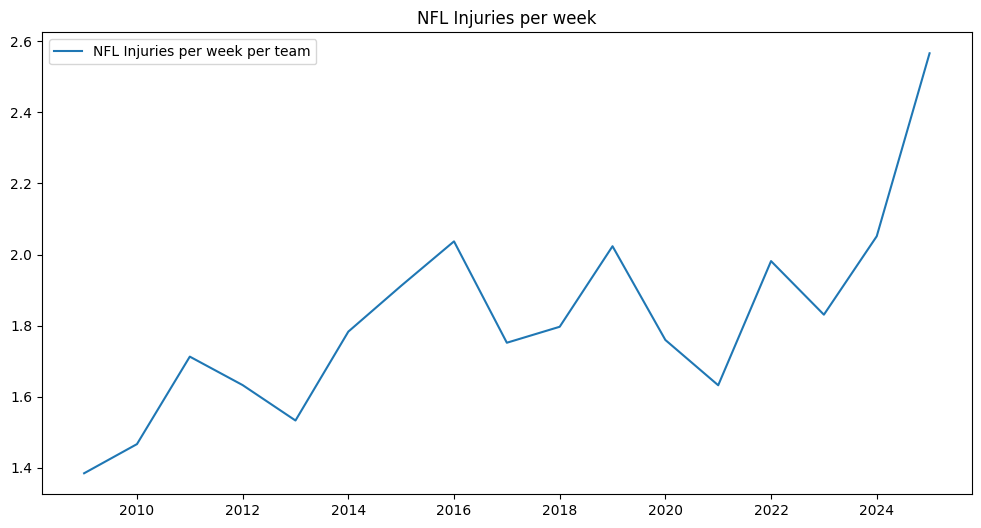

In [27]:
x=nfl_injuries_league['season'].to_pandas()
y=nfl_injuries_league['num_out_per_team_per_week'].to_pandas()

plt.figure(figsize=(12,6))
plt.plot(x,y,label='NFL Injuries per week per team')
plt.title('NFL Injuries per week')
plt.legend()
plt.show()

CFB Injury Proxy

## Expected Player Absence Proxy

I constructed an expected player absence proxy using player-level college football box-score data. The goal was to identify team-games where recently important players disappeared from the current game’s box score. This should be interpreted as an absence proxy, not a confirmed injury measure, because a missing player could be injured, benched, suspended, resting, transferred, or missing because of data limitations.

### 1. Pull game and player-stat data

First, I pulled FBS game data from the CollegeFootballData `/games` endpoint for seasons 2005–2025.

Then, for each season and week, I pulled player game statistics from the `/games/players` endpoint.

The player-stat data were originally nested, so I flattened them into a long player-game-stat dataset with identifiers like:

```python
game_id
team
conference
home_away
player_id
player_name
category
stat_type
stat
```

Each row represented one player-stat entry in one game.

### 2. Convert player stats from long to wide

Next, I converted the long player-stat dataset into a wide player-game dataset. In the wide version, each row is one player in one game, and each statistic becomes its own column.

For example, passing yards, rushing yards, receiving yards, tackles, sacks, and interceptions become separate variables when available.

I also created a `player_key` to track players across games:

```python
player_key = player_id if player_id is available else normalized_player_name
```

The normalized player name was lowercased and stripped of periods, commas, and extra spaces.

### 3. Create a production score

For each player-game, I created a rough production/usage score from the available box-score statistics:

```python
production_score =
    0.04 * pass_yards_proxy
  + 0.10 * rush_yards_proxy
  + 0.10 * rec_yards_proxy
  + 4.00 * td_proxy
  + 0.15 * pass_attempts_proxy
  + 0.25 * rush_attempts_proxy
  + 0.50 * receptions_proxy
  + 0.75 * tackles_proxy
  + 2.00 * sacks_proxy
  + 3.00 * interceptions_proxy
```

This score is not intended to be a formal player-value metric. It is only used to identify players who were recently involved enough that their disappearance from the box score likely matters.

I also created a quarterback-like game indicator:

```python
qb_like_game = pass_attempts_proxy >= 8
```

Before constructing the absence proxy, I kept only player-game rows with positive production:

```python
production_score > 0
```

### 4. Create a team-game dataset

I converted the game-level dataset into a team-game dataset with two rows per game:

- one row for the home team
- one row for the away team

Each team-game row contains:

```python
game_id
season
week
season_type
game_start_time
team
opponent
home_away
```

Then I sorted team-games within each team-season:

```python
team_games = team_games.sort_values(
    ["team", "season", "week", "game_start_time", "game_id"]
)
```

The absence proxy is therefore constructed within each team-season, not across seasons.

### 5. Define the lookback window

For each team-game, I looked back at the team’s previous four games:

```python
LOOKBACK_GAMES = 4
```

For a given team-game, the prior games are the previous four game IDs for that team in the same season:

```python
prior_game_ids = previous 4 game_ids for that team in the same season
```

Then I split the player-game data into two groups:

```python
prior = player stats from the prior 4 games
current = player stats from the current game
```

If a team-game had no prior games, the absence variables were set to zero.

### 6. Define expected players

A player was classified as expected for the current game if they met both of the following conditions in the lookback window:

```python
prior_games_played >= 2
prior_avg_prod >= 5.0
```

where:

```python
prior_games_played = number of distinct prior games where the player appeared
prior_avg_prod = average production_score across prior games
```

So with the baseline settings:

```python
MIN_PRIOR_GAMES = 2
MIN_AVG_PROD_SCORE = 5.0
```

a player had to appear in at least two of the previous four games and average at least 5.0 production points to be considered expected.

For each expected player, I also calculated:

```python
prior_sum_prod
prior_qb_like_games
prior_pass_attempts
prior_rush_attempts
prior_receptions
prior_tackles
```

A player was flagged as QB-like if they had at least one QB-like game in the lookback window:

```python
qb_like_player = prior_qb_like_games >= 1
```

### 7. Define `is_missing`

For the current game, I created the set of players who appeared in the current game’s box score:

```python
current_keys = set(current["player_key"].dropna().astype(str))
```

Then I flagged expected players as missing if their `player_key` did not appear in the current game:

```python
expected["is_missing"] = ~expected["player_key"].astype(str).isin(current_keys)
```

Therefore:

```python
is_missing = True
```

means the player was expected based on recent participation and production, but did not appear in the current game’s player-stat data.

In words, the logic is:

> If a player was recently active and productive for a team, but that player does not appear in the current game’s box score, classify the player as a missing expected player.

### 8. Aggregate missing players to the team-game level

After identifying missing expected players, I aggregated the missing-player information to the team-game level.

For each team-game, I calculated:

```python
missing_expected_players = number of expected players missing from the current box score

missing_expected_prod_sum = sum of prior_avg_prod among missing expected players

prior_expected_prod_sum = sum of prior_avg_prod among all expected players

missing_expected_prod_share = missing_expected_prod_sum / prior_expected_prod_sum

missing_expected_qb_like_players = number of missing expected players classified as QB-like

num_expected_players = total number of expected players
```

If `prior_expected_prod_sum` was zero, I set:

```python
missing_expected_prod_share = 0.0
```

### 9. Output datasets

The procedure produces two datasets.

The first is a team-game summary dataset with one row per team-game:

```python
season
week
season_type
game_id
team
opponent
home_away
missing_expected_players
missing_expected_prod_sum
missing_expected_prod_share
missing_expected_qb_like_players
num_expected_players
prior_expected_prod_sum
```

The second is a missing-player detail dataset with one row per missing expected player:

```python
season
week
season_type
game_id
team
opponent
home_away
player_key
player_name
prior_games_played
prior_avg_prod
prior_sum_prod
qb_like_player
prior_pass_attempts
prior_rush_attempts
prior_receptions
prior_tackles
```

### 10. Interpretation

The main proxy is:

```python
missing_expected_prod_share
```

This measures the share of a team’s recently expected production that disappeared from the current game’s box score.

A higher value means that a larger share of the team’s recent production was missing in that game. Because the measure is weighted by recent production, missing a high-usage player counts more than missing a low-usage player.

This should be interpreted as an expected player absence proxy rather than a pure injury measure. It can capture injuries, but it can also capture benchings, suspensions, transfers, rotation changes, rest, players who appeared without recording a tracked statistic, or missing player-stat data.

In [31]:
cfb_injury=pl.read_csv(r'/home/porter/Desktop/cfb-projects/cfb data/cfb_missing_expected_players_detail_2005_2025.csv')
cfb_injury

season,week,season_type,game_id,team,opponent,home_away,player_key,player_name,prior_games_played,prior_avg_prod,prior_sum_prod,qb_like_player,prior_pass_attempts,prior_rush_attempts,prior_receptions,prior_tackles
i64,i64,str,i64,str,str,str,i64,str,i64,f64,f64,bool,f64,f64,f64,f64
2020,12,"""regular""",401248275,"""Abilene Christian""","""Virginia""","""away""",4573378,"""Taelyn Williams""",2,67.325,134.65,false,0.0,0.0,245.5,0.0
2005,3,"""regular""",252602005,"""Air Force""","""Wyoming""","""home""",147734,"""Adam Fitch""",2,5.775,11.55,false,0.0,5.0,0.0,0.0
2005,5,"""regular""",252720036,"""Air Force""","""Colorado State""","""away""",164362,"""Justin Handley""",4,11.6875,46.75,false,0.0,12.0,61.5,0.0
2005,5,"""regular""",252720036,"""Air Force""","""Colorado State""","""away""",168332,"""Bobby Giannini""",2,55.5,111.0,false,0.0,0.0,0.0,0.0
2005,6,"""regular""",252812426,"""Air Force""","""Navy""","""away""",147734,"""Adam Fitch""",3,6.786667,20.36,false,0.0,12.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025,13,"""regular""",401760419,"""Wyoming""","""Nevada""","""home""",5296625,"""Landon Sims""",2,9.455,18.91,false,0.0,9.0,0.0,0.0
2025,14,"""regular""",401760424,"""Wyoming""","""Hawai'i""","""away""",5193298,"""Chris Durr Jr.""",3,49.4,148.2,false,0.0,0.0,260.8,0.0
2025,14,"""regular""",401760424,"""Wyoming""","""Hawai'i""","""away""",5258056,"""Samuel Harris""",4,16.5625,66.25,false,0.0,31.0,81.0,0.0


In [39]:
cfb_games=pl.read_parquet(r'/home/porter/Desktop/cfb-projects/cfb data/merged_team_season_all.parquet')
cfb_games=cfb_games.select(['team','season','record_classification','record_total_games'])
cfb_games=cfb_games.filter(pl.col('record_total_games').is_not_null())
cfb_games

team,season,record_classification,record_total_games
str,i64,str,f64
"""Air Force""",2006,"""fbs""",12.0
"""Akron""",2006,"""fbs""",12.0
"""Alabama""",2006,"""fbs""",13.0
"""Alabama A&M""",2006,"""fcs""",1.0
"""Alabama State""",2006,"""fcs""",1.0
…,…,…,…
"""Worcester Polytechnic Institut…",2025,"""iii""",10.0
"""Worcester St""",2025,"""iii""",10.0
"""Wyoming""",2025,"""fbs""",12.0


In [ ]:
cfb_injury_season=cfb_injury.group_by(['week','team','season']).agg(pl.col('player_name').len())
cfb_injury_season=cfb_injury_season.join(cfb_games,on=['team','season'])
cfb_injury_season=cfb_injury_season.filter(pl.col('record_classification')=='fbs') #subset to only fbs

In [42]:
cfb_injury_season

week,team,season,player_name,record_classification,record_total_games
i64,str,i64,u32,str,f64
13,"""Notre Dame""",2016,4,"""fbs""",12.0
12,"""Minnesota""",2023,3,"""fbs""",13.0
6,"""SMU""",2012,3,"""fbs""",13.0
9,"""Georgia""",2006,6,"""fbs""",13.0
3,"""South Florida""",2016,2,"""fbs""",13.0
…,…,…,…,…,…
12,"""Washington State""",2019,2,"""fbs""",13.0
6,"""Nebraska""",2011,3,"""fbs""",13.0
6,"""East Carolina""",2024,2,"""fbs""",13.0


In [68]:
cfb_injury_season_real=cfb_injury_season.group_by(['season','team','record_total_games']).agg(pl.col('player_name').sum())
num_teams=cfb_injury_season_real.group_by(['season']).agg(pl.col('team').len())
num_teams=num_teams.rename({'team':'num_teams'})
cfb_injury_season_real=cfb_injury_season_real.join(num_teams,on=['season'])


cfb_injury_season_per_week=cfb_injury_season_real.with_columns(
    (pl.col('player_name')/(pl.col('record_total_games')-1)).alias('per_week')
)
# cfb_injury_season_per_week=cfb_injury_season_per_week.with_columns(
#     (pl.col('player_name')/pl.col('num_teams')).alias('n_per_team')
# )


cfb_injury_season_per_week=cfb_injury_season_per_week.with_columns(
    pl.col('season').cast(pl.Float64).alias('season')
)
cfb_injury_season_per_week

season,team,record_total_games,player_name,num_teams,per_week
f64,str,f64,u32,u32,f64
2012.0,"""Boise State""",13.0,26,124,2.166667
2015.0,"""Utah State""",13.0,31,128,2.583333
2013.0,"""Nevada""",12.0,26,125,2.363636
2019.0,"""Arizona""",12.0,35,130,3.181818
2021.0,"""Houston""",14.0,32,130,2.461538
…,…,…,…,…,…
2010.0,"""Air Force""",13.0,27,120,2.25
2020.0,"""Baylor""",9.0,28,127,3.5
2019.0,"""Rutgers""",12.0,41,130,3.727273


In [72]:
cfb_injury_season_per_week_league=cfb_injury_season_per_week.group_by(['season']).agg(pl.col('per_week').mean())
cfb_injury_season_per_week_league=cfb_injury_season_per_week_league.sort(['season'],descending=False)
cfb_injury_season_per_week_league=cfb_injury_season_per_week_league.filter(pl.col('season')>2008)
cfb_injury_season_per_week_league

season,per_week
f64,f64
2009.0,2.442463
2010.0,2.323665
2011.0,2.522708
2012.0,2.440469
2013.0,2.642685
…,…
2021.0,2.683431
2022.0,2.744782
2023.0,2.713433


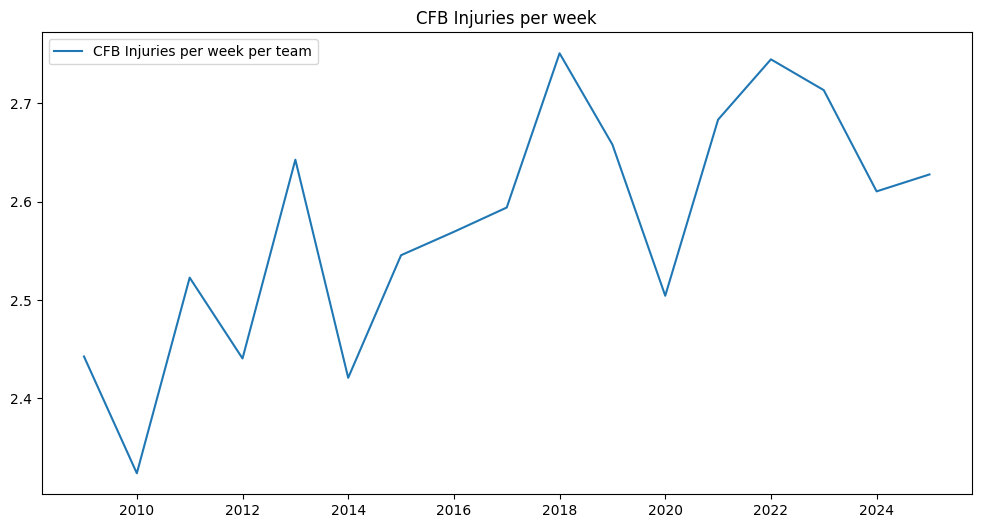

In [73]:
x=cfb_injury_season_per_week_league['season'].to_pandas()
y=cfb_injury_season_per_week_league['per_week'].to_pandas()

plt.figure(figsize=(12,6))
plt.plot(x,y,label='CFB Injuries per week per team')
plt.title('CFB Injuries per week')
plt.legend()
plt.show()

#### Establishing Paralell Trends

In [74]:
combined=nfl_injuries_league.join(cfb_injury_season_per_week_league,on=['season'])
combined

season,num_out,num_injury_report_rows,num_out_per_team,num_out_per_team_per_week,per_week
f64,i64,i64,f64,f64,f64
2009.0,709,4821,22.15625,1.384766,2.442463
2010.0,751,4491,23.46875,1.466797,2.323665
2011.0,877,4971,27.40625,1.712891,2.522708
2012.0,836,5533,26.125,1.6328125,2.440469
2013.0,785,5070,24.53125,1.533203,2.642685
…,…,…,…,…,…
2021.0,888,5587,27.75,1.632353,2.683431
2022.0,1078,5682,33.6875,1.981618,2.744782
2023.0,996,5599,31.125,1.830882,2.713433


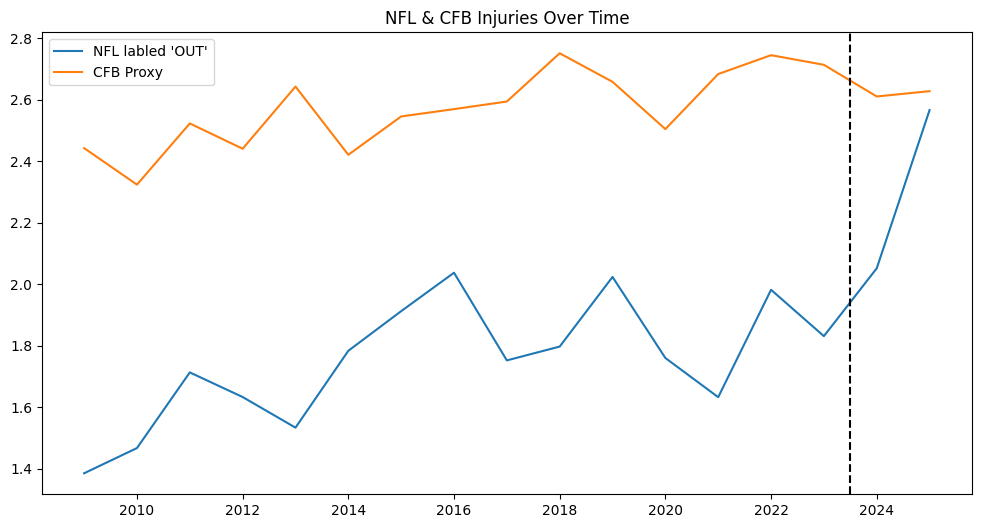

In [82]:
y1=combined['num_out_per_team_per_week'].to_pandas()
y2=combined['per_week'].to_pandas()

x=combined['season'].to_pandas()


plt.figure(figsize=(12,6))
plt.title('NFL & CFB Injuries Over Time')
plt.plot(x,y1,label='NFL labled \'OUT\'')
plt.plot(x,y2,label='CFB Proxy')
plt.axvline(x=2023.5,c='black',linestyle='--')
plt.legend()
plt.show()

In [92]:
combined_pre_treat=combined.filter(pl.col('season')<2024)
nfl_time_series=combined_pre_treat['num_out_per_team_per_week'].to_pandas()
cfb_time_series=combined_pre_treat['per_week'].to_pandas()

print(np.corrcoef(cfb_time_series,nfl_time_series))


diff_avg=cfb_time_series-nfl_time_series

[[1.         0.50600256]
 [0.50600256 1.        ]]


In [94]:
diff_avg.mean()

np.float64(0.8211180283957766)

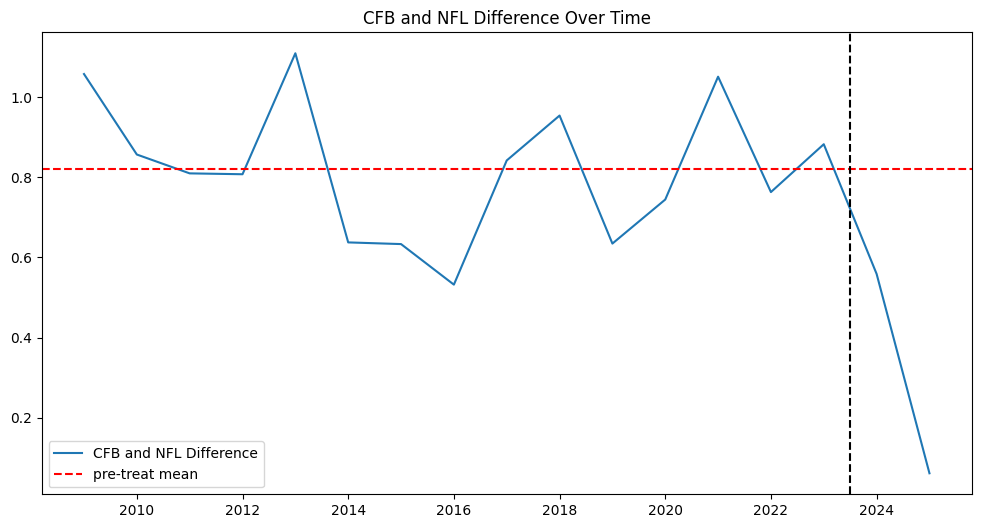

In [97]:
diff=y2-y1



plt.figure(figsize=(12,6))
plt.plot(x,diff,label='CFB and NFL Difference')
plt.title('CFB and NFL Difference Over Time')
plt.axhline(y=diff_avg.mean(),c='red',linestyle='--',label='pre-treat mean')
plt.axvline(x=2023.5,c='black',linestyle='--')
plt.legend()

plt.show()


#### Diff in Diff